# Preprocesamiento

Este notebook parte de los datos de los doce sensores seleccionados en "seleccion_sensores.ipynb" y construye, para cada uno de ellos, la serie temporal completa en intervalos temporales de 15 minutos del periodo de estudio 2023-2025. A diferencia de los análisis exploratorios previos, aquí no se agregan los registros, sino que se conserva la dimensión temporal por ser la base del entrenamiento posterior de los modelos.

## Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import optuna
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
optuna.logging.set_verbosity(optuna.logging.WARNING)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from matplotlib.ticker import PercentFormatter

c:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\TFM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\dataset')

CARPETA_ENTRADA = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\resultados\\sensores')
CARPETA_SALIDA   = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\resultados\\preprocesamiento-transformacion')
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

SEPARADOR     = ';'
FORMATO_FECHA = '%Y-%m-%d %H:%M:%S'
TAM_BLOQUE    = 2_000_000

# Variables cuantitativas
VARIABLES = ['intensidad', 'ocupacion', 'carga']

# Frecuencia de los rejistros
FREQ = '15min'

# Parámetros de limpieza
HUECO_MAX_INTERP = 8      # 8 intervalos de 15 min = 2 horas
FACTOR_IQR       = 1.5    # factor estándar de Tukey para outliers

FICHEROS_HISTORICO = {f"{mes:02d}{año}": BASE_DIR / "historico" / f"{mes:02d}{año}.zip" for año in range(2023, 2026) for mes in range(1, 13)}

### Carga de los 12 sensores seleccionados

Se leen los identificadores de los sensores seleccionados junto con su tipología, que se conserva para los análisis posteriores diferenciados por tipo de vía.

In [3]:
sel = pd.read_csv(CARPETA_ENTRADA / 'sensores_seleccionados_chamberi.csv')
sel['id'] = sel['id'].astype(str).str.strip()

IDS_SENSORES = sel['id'].tolist()
TIPOLOGIA = sel.set_index('id')['tipologia'].to_dict()

print(f'Sensores seleccionados: {len(IDS_SENSORES)}')
print(sel[['id', 'nombre_via', 'tipologia']].to_string(index=False))

Sensores seleccionados: 12
   id                                                    nombre_via   tipologia
 4421               Cea Bermúdez, 4 O-E(Boix y Morer-Bravo Murillo)   Principal
 5774                       Av.Moncloa O-E  - La Granja - Del Valle    Arterial
 5777 Av. Reina Victoria O-E  - Gral. Ibáñez Íbero - Pablo Iglesias    Arterial
10604   Blasco de Garay S-N (Alberto Aguilera -Rodríguez San Pedro) Residencial
 3469 SAN FRANCISCO DE SALES S-N (ANDRES MELLADO - GUZMAN EL BUENO) Residencial
 4428        Gral. Martinez Campos, 24 O-E(Fdez. de la Hoz-Zurbano)  Secundaria
 4433        José Abascal, 52 O-E(Alvarez de Castro-Santa Engracia)   Principal
 5711                 Raimundo Fdez.Villaverde O-E - Alenza-Ponzano   Principal
 4434              Eloy Gonzalo O-E(Juan de Austria-Santa Engracia) Residencial
 5778    Gral. Ibáñez Íbero S-N  - Francisco Sales - Reina Victoria  Secundaria
10603               Fernández de los Rios O-E(Galileo-Vallehermoso)    Arterial
 4457        

### Lectura del histórico

Se cargan los registros cada 15 minutos de los 12 sensores durante el periodo completo 2023-2025. Se tiene en cuenta que si son valores negativos se tratan como nulos como específica la documentación de los conjuntos de datos.

In [4]:
COLUMNAS = ['id', 'fecha','error'] + VARIABLES
acumulado = []

for nombre, ruta in FICHEROS_HISTORICO.items():
    print(f"  {nombre} ", end=" ")
    filas_mes = 0

    for bloque in pd.read_csv(ruta, sep=SEPARADOR, usecols=COLUMNAS,chunksize=TAM_BLOQUE, encoding='latin-1',compression='zip'):
        bloque['id'] = bloque['id'].astype(str).str.strip()
        bloque = bloque[bloque['id'].isin(IDS_SENSORES)].copy()
        if bloque.empty:
            continue
        for v in VARIABLES:
            bloque[v] = pd.to_numeric(bloque[v], errors='coerce')
            bloque.loc[bloque[v] < 0, v] = np.nan # Valores negativos son nulos

        bloque['fecha'] = pd.to_datetime(bloque['fecha'], format=FORMATO_FECHA,errors='coerce')
        bloque = bloque.dropna(subset=['fecha'])
        acumulado.append(bloque)
        filas_mes += len(bloque)
    print(f"{filas_mes:,} registros")

df = pd.concat(acumulado, ignore_index=True)
del acumulado

print(f"\nTotal registros: {len(df):,}")
print(f"Sensores únicos: {df['id'].nunique()}")
print(f"Periodo: {df['fecha'].min()} a {df['fecha'].max()}")

  012023  35,533 registros
  022023  32,190 registros
  032023  35,524 registros
  042023  34,503 registros
  052023  35,662 registros
  062023  34,504 registros
  072023  35,665 registros
  082023  35,445 registros
  092023  34,317 registros
  102023  35,657 registros
  112023  34,496 registros
  122023  35,470 registros
  012024  35,596 registros
  022024  33,272 registros
  032024  35,553 registros
  042024  34,483 registros
  052024  35,302 registros
  062024  34,436 registros
  072024  35,653 registros
  082024  35,211 registros
  092024  34,455 registros
  102024  35,356 registros
  112024  34,137 registros
  122024  35,557 registros
  012025  35,323 registros
  022025  32,187 registros
  032025  35,588 registros
  042025  32,181 registros
  052025  35,606 registros
  062025  34,215 registros
  072025  35,636 registros
  082025  35,459 registros
  092025  34,407 registros
  102025  35,492 registros
  112025  34,203 registros
  122025  34,450 registros

Total registros: 1,252,724


## Análisis exploratorio

En primer lugar, se comienza realizando un análisis exploratorio de los datos procedentes de los sensores seleccionados. Para ello, se analiza la distribución y correlación de las variables de entrada y la variable objetivo. Para el estudio de las distribuciones de cada variable se lleva a cabo el análisis de los histogramas y estadísticos como la media, mediana y los coeficientes de asimetría y curtosis, para determinar su grado de ajuste a una distribución normal, ya que esto condiciona en la elección de un modelo paramétrico o no paramétrico. 

### Distribuciones de las variables

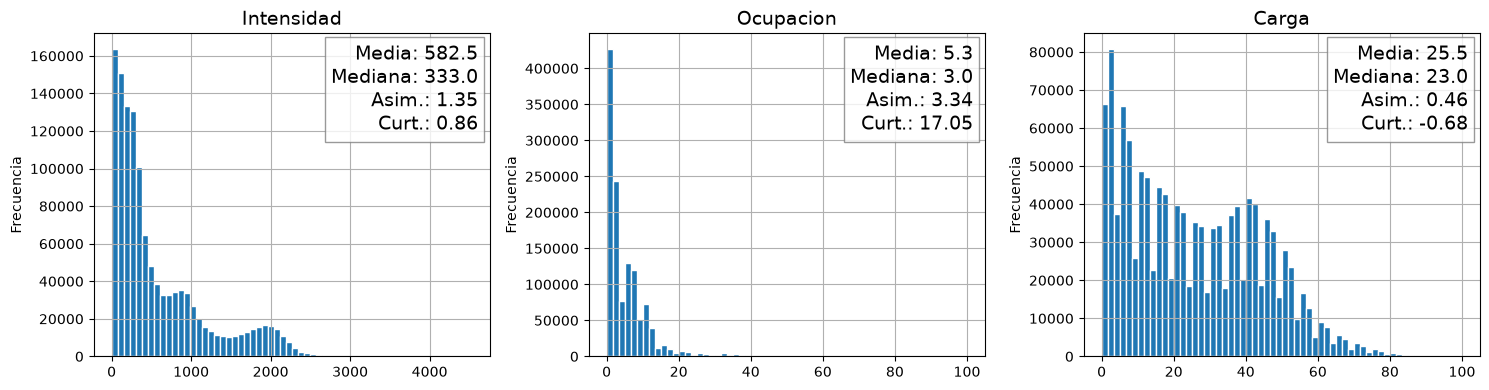

In [5]:
axes = df[VARIABLES].hist(figsize=(15, 4),bins=60,edgecolor='white',layout=(1, 3))

for ax, v in zip(axes.flatten(), VARIABLES):
    media = df[v].mean()
    mediana = df[v].median()
    asimetria = stats.skew(df[v].dropna())
    curtosis = stats.kurtosis(df[v].dropna(), fisher=True)
    ax.set_ylabel("Frecuencia")
    ax.set_title(v.capitalize(), fontsize=14)
    texto = (f"Media: {media:.1f}\n" f"Mediana: {mediana:.1f}\n "f"Asim.: {asimetria:.2f}\n" f"Curt.: {curtosis:.2f}")
    ax.text( 0.97, 0.97, texto,transform=ax.transAxes,fontsize=14,va="top",ha="right",bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

plt.tight_layout()

imagen = CARPETA_SALIDA / "distribucion_variables.png"
plt.savefig(imagen, dpi=300, bbox_inches="tight")
plt.show()

### Correlación entre las variables

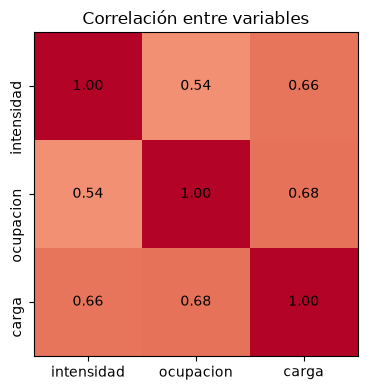

In [6]:
corr = df[VARIABLES].corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(VARIABLES))); 
ax.set_xticklabels(VARIABLES)
ax.set_yticks(range(len(VARIABLES))); 
ax.set_yticklabels(VARIABLES, rotation = 90)
for i in range(len(VARIABLES)):
    for j in range(len(VARIABLES)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')
ax.set_title('Correlación entre variables')
plt.tight_layout()
imagen = CARPETA_SALIDA / "correlacion_variables.png"
plt.savefig(imagen, dpi=300, bbox_inches="tight")
plt.show()

## Calidad
En segundo lugar, se evalúa la calidad del conjunto de datos mediante el análisis e identificación de valores nulos y atípicos. Los intervalos de datos faltantes con una duración máxima de dos horas se completan mediante interpolación lineal entre los valores adyacentes. Sin embargo, en los huecos de mayor duración se mantienen como faltantes, ya que su estimación podría introducir ruido y modificar el comportamiento real de los datos. Así mismo, tampoco es correcto excluir los días completos ya que los modelos que se van a emplear operan sobre observaciones individuales sin requerir continuidad temporal estricta y perderíamos registros útiles para el entrenamiento del modelo. Por otro lado, se estudian los atípicos por tipo de día (laborable / no laborable) y hora. Debido a la naturaleza del fenómeno estudiado, se analiza la distribución de los outliers para determinar si representan variaciones propias del tráfico o si por el contrario deben considerarse y tratarse como anómalos.

### Errores

Se comprueba si existen registros con valores negativos ya que el dataset indica que son valores erróneos. Además, se utiliza la variable error por si hay algún registro en el que ha habido problemas al medirlo. 

In [7]:
for v in VARIABLES:
    df_pos = df[df[v] < 0]  
    a=df_pos.count()   
    print(f'Valores negativos variable {v}\n{a}')  
df["error"].value_counts()           

Valores negativos variable intensidad
id            0
fecha         0
intensidad    0
ocupacion     0
carga         0
error         0
dtype: int64
Valores negativos variable ocupacion
id            0
fecha         0
intensidad    0
ocupacion     0
carga         0
error         0
dtype: int64
Valores negativos variable carga
id            0
fecha         0
intensidad    0
ocupacion     0
carga         0
error         0
dtype: int64


error
N    1252724
Name: count, dtype: int64

### Valores nulos



In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1252724 entries, 0 to 1252723
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   id          1252724 non-null  str           
 1   fecha       1252724 non-null  datetime64[us]
 2   intensidad  1252724 non-null  float64       
 3   ocupacion   1252724 non-null  float64       
 4   carga       1252724 non-null  float64       
 5   error       1252724 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 63.8 MB


A pesar de que no nos aparece ningún registro con valores nulos, teniendo en cuenta que debemos de tener los registros de los 12 sensores cada 15 minutos durante 3 años de los cuales uno es bisito, deberáimos tener un total de: 

In [9]:
print(f'Deberíamos tener {(365*2 +366)*24*4*12} registros ({(365*2 +366)*24*4} por sensor)') 

Deberíamos tener 1262592 registros (105216 por sensor)


In [10]:
print(f'Nos faltan {(365*2 +366)*24*4*12-1252724} registros') 

Nos faltan 9868 registros


Por lo que se va a construir una rejilla completa de los instantes que deberían existir y fuerza a cada serie a alinearse con ella. Donde el sensor no reportó, aparece ahora una fila con NaN. 

In [11]:
# Rejilla común para todos los sensores
inicio = df['fecha'].min().floor('D')
fin    = df['fecha'].max().ceil('D') - pd.Timedelta(FREQ)
rejilla = pd.date_range(inicio, fin, freq=FREQ)
print(f'Rejilla: {len(rejilla):,} instantes por sensor ({len(rejilla)*12:,} instantes totales)')
print(f'Periodo: {inicio.date()} a {fin.date()}')

series = {}
for sid in IDS_SENSORES:
    s = (df[df['id'] == sid]
         .drop_duplicates(subset='fecha').set_index('fecha')[VARIABLES].reindex(rejilla))
    s.index.name = 'fecha'
    series[sid] = s

Rejilla: 105,216 instantes por sensor (1,262,592 instantes totales)
Periodo: 2023-01-01 a 2025-12-31


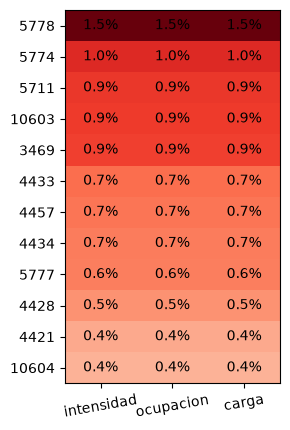

In [12]:
# Nulos por sensor antes de limpiar
nulos = pd.DataFrame({sid: series[sid][VARIABLES].isna().mean() for sid in IDS_SENSORES}).T
nulos_ord = nulos.loc[nulos.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(3, 0.2 * len(IDS_SENSORES) + 2))
im = ax.imshow(nulos_ord.values * 100, aspect='auto', cmap='Reds', vmin=0)
ax.set_xticks(range(len(nulos_ord.columns)))
ax.set_xticklabels(VARIABLES, rotation=10, ha='center')
ax.set_yticks(range(len(nulos_ord.index)))
ax.set_yticklabels(nulos_ord.index)

for i in range(nulos_ord.shape[0]):
    for j in range(nulos_ord.shape[1]):
        val = nulos_ord.values[i, j] * 100
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                color='white' if val > 50 else 'black', fontsize=10)

plt.tight_layout()
imagen = CARPETA_SALIDA / "nulos_sensor_resumen.png"
plt.savefig(imagen, dpi=300, bbox_inches="tight")

plt.show()

El porcentaje de valores nulos es el mismo en las tres variables para cada sensor, lo que tiene sentido ya que hemos visto anteriormente que todos los valores nulos vienen del proceso de reindexación, es decir son marcas tmeporales en las que los sensores no registraron datos para ninguna de las tres variables. No existen, por tanto, nulos que afecten a una variable de manera aislada, por lo que el análisis agregado de las tres variables es representativo y no existe necesidad de desglose individual.
Vamos a ver la evolución temporal de los sensores: 

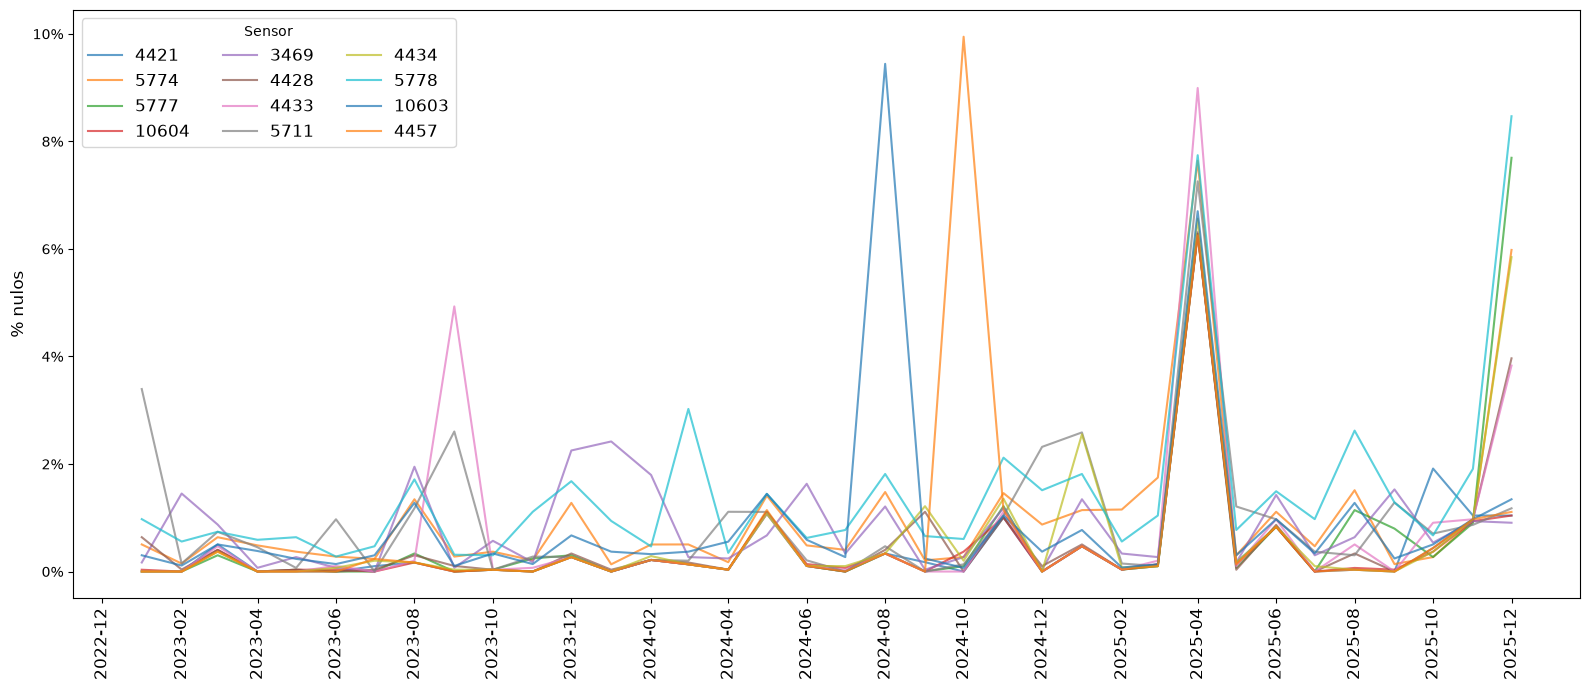

In [13]:
fig, ax = plt.subplots(figsize=(16, 7))

for sid in IDS_SENSORES:
    s = series[sid][VARIABLES]
    nulos_mes = s.isna().mean(axis=1).resample('MS').mean() * 100
    ax.plot(nulos_mes.index, nulos_mes.values, label=str(sid),alpha=0.7, linewidth=1.5)

ax.set_ylabel('% nulos',fontsize=12)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.legend(title='Sensor', ncol=3, fontsize=12, loc='upper left')
plt.tight_layout()
imagen = CARPETA_SALIDA / "nulos_sensor_evolucion_mensual.png"
plt.savefig(imagen, dpi=300, bbox_inches="tight")
plt.show()

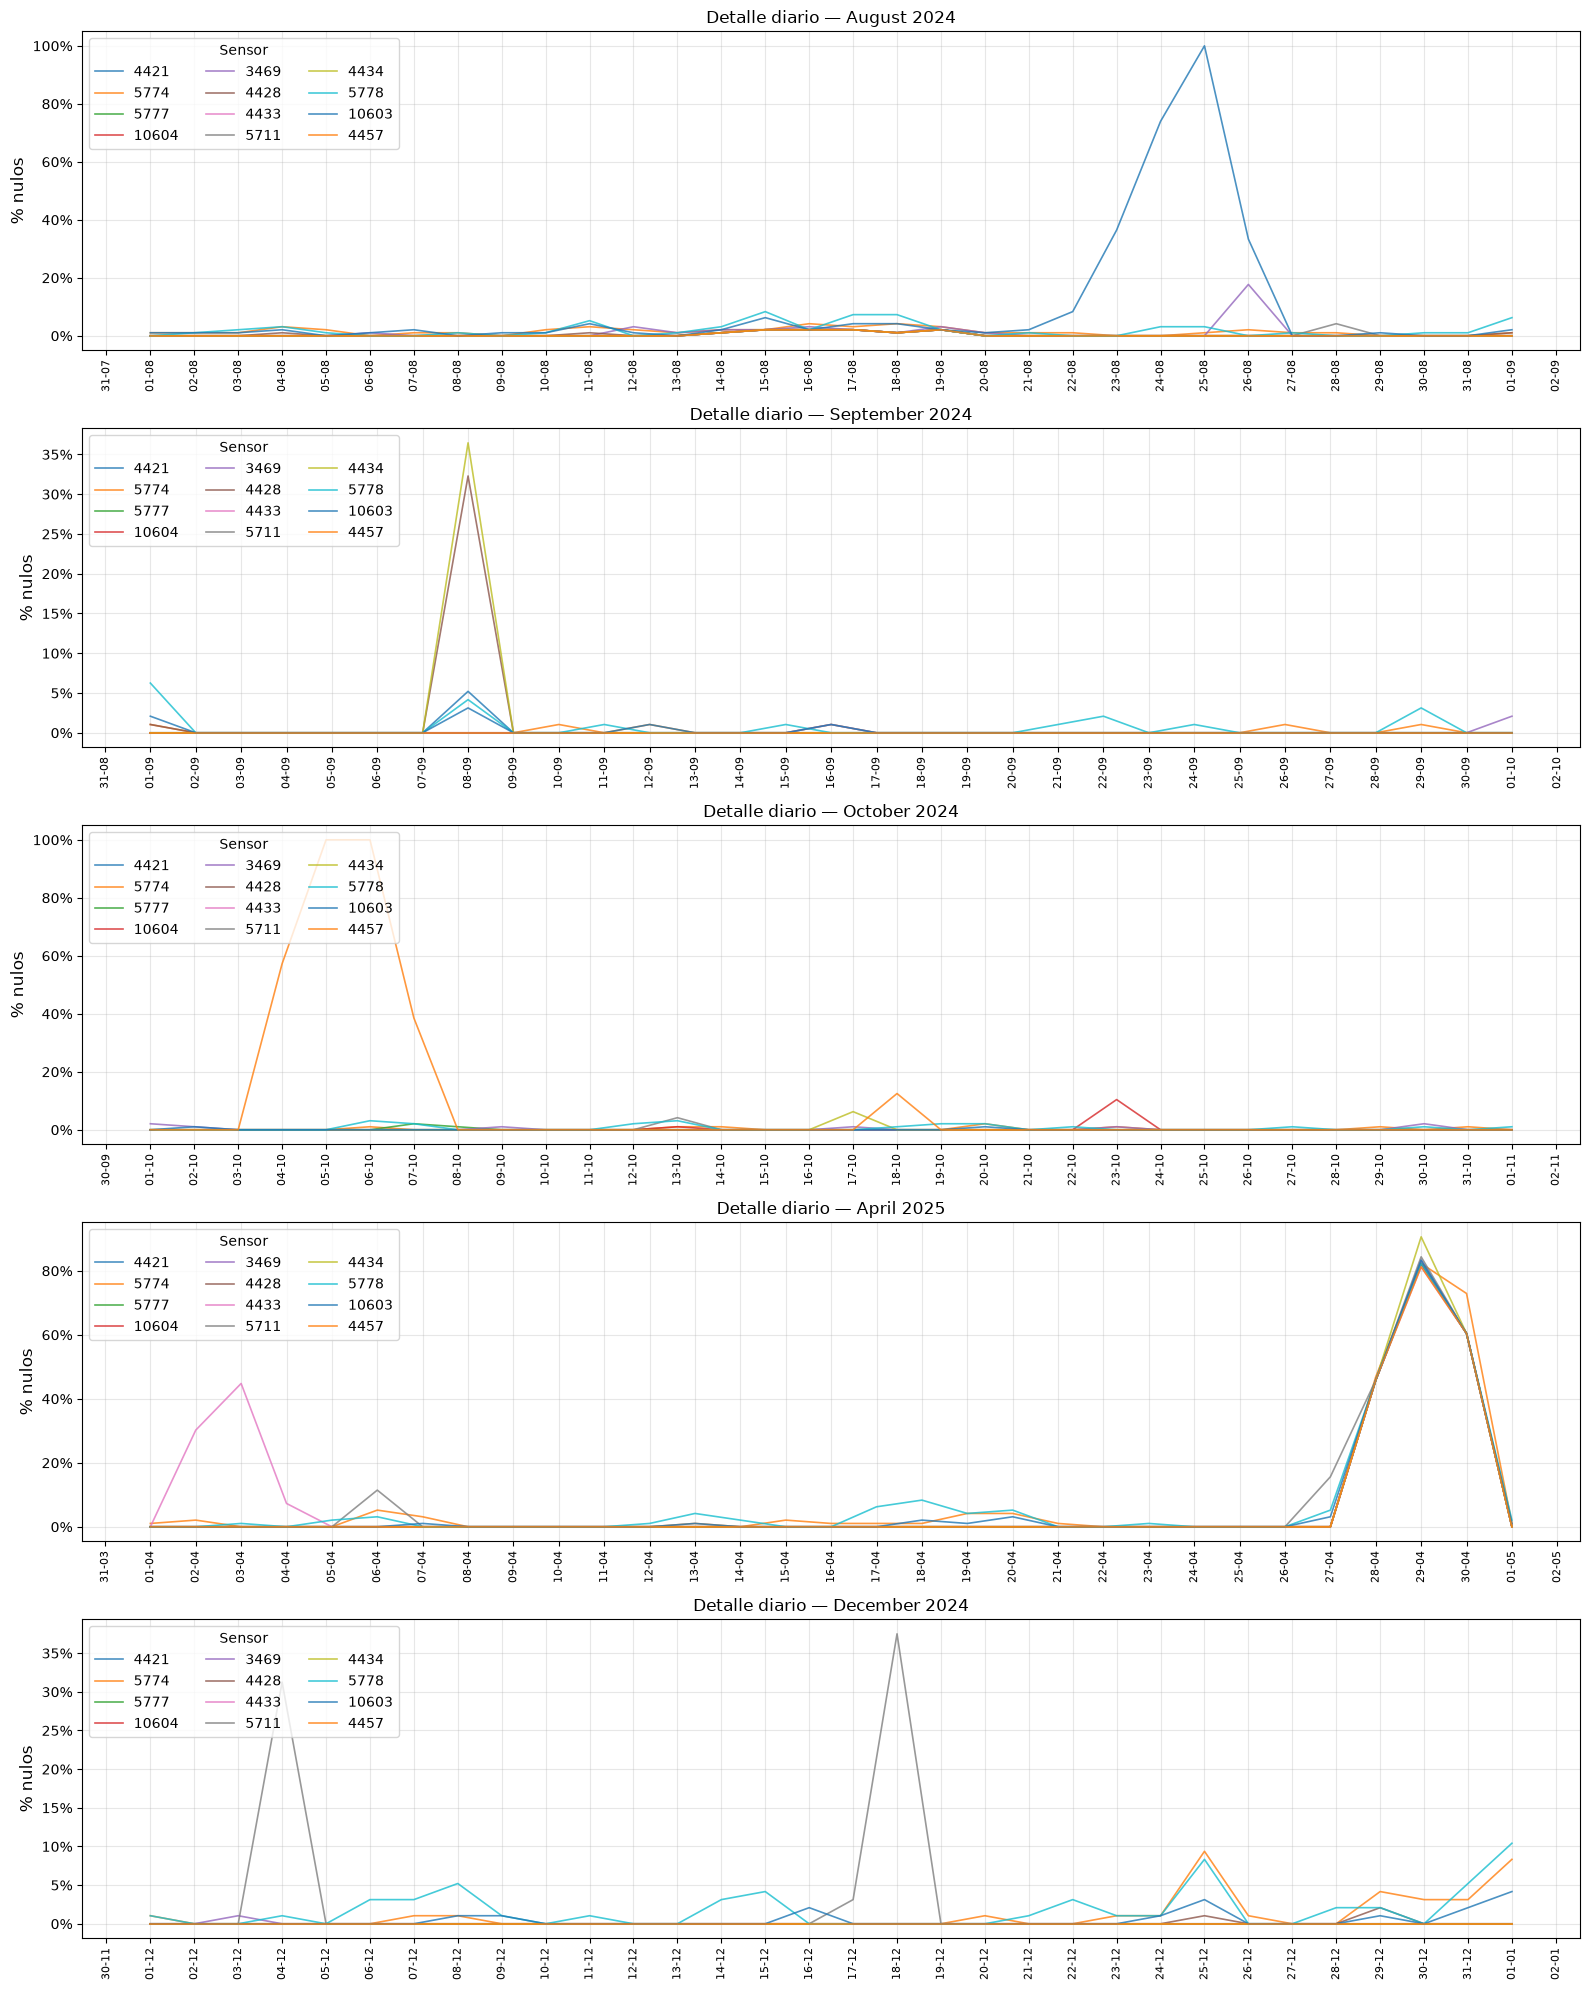

In [14]:
MESES_ZOOM = ['2024-08','2024-09','2024-10' , '2025-04','2024-12']

meses_peores = pd.to_datetime(MESES_ZOOM)
N_PEORES = len(MESES_ZOOM)
fig, axes = plt.subplots(N_PEORES, 1, figsize=(16, 4 * N_PEORES), sharex=False)
if N_PEORES == 1:
    axes = [axes]

for ax, mes in zip(axes, meses_peores):
    inicio_zoom = mes
    fin_zoom = mes + pd.DateOffset(months=1) 

    for sid in IDS_SENSORES:
        s = series[sid][VARIABLES]
        nulos_dia = s.isna().mean(axis=1).resample('D').mean() * 100
        ventana = nulos_dia[(nulos_dia.index >= inicio_zoom) &(nulos_dia.index <= fin_zoom)]
        ax.plot(ventana.index, ventana.values, label=str(sid),
                alpha=0.8, linewidth=1.2)

    ax.set_title(f'Detalle diario — {mes.strftime("%B %Y")}', fontsize=12)
    ax.set_ylabel('% nulos', fontsize=12)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(alpha=0.3)
    ax.legend(title='Sensor', ncol=3, fontsize=10, loc='upper left')

plt.tight_layout()
imagen = CARPETA_SALIDA / "nulos_detalle_meses_peores.png"
plt.savefig(imagen, dpi=300, bbox_inches="tight")
plt.show()

#### Tratamiento de nulos

Los huecos de duración igual o inferior a dos horas (ocho intervalos consecutivos) se estiman mediante interpolación lineal entre los valores adyacentes, dado que en esa ventana la carga de tráfico evoluciona de forma suficientemente suave como para que la estimación introduzca un error reducido. Los huecos superiores a dos horas se mantienen como nulos, ya que abarcan cambios de régimen del tráfico que una interpolación lineal no puede reproducir de forma fiable; su tratamiento se resuelve en la posterior exclusión de días.

       nulos_intensidad  nulos_ocupacion  nulos_carga
4421           0.141613         0.141613     0.141613
5774           0.579760         0.579760     0.579760
5777           0.155870         0.155870     0.155870
10604          0.120704         0.120704     0.120704
3469           0.313641         0.313641     0.313641
4428           0.149217         0.149217     0.149217
4433           0.126407         0.126407     0.126407
5711           0.220499         0.220499     0.220499
4434           0.142564         0.142564     0.142564
5778           0.936169         0.936169     0.936169
10603          0.399179         0.399179     0.399179
4457           0.139713         0.139713     0.139713
nulos.columns: ['nulos_intensidad', 'nulos_ocupacion', 'nulos_carga']
nulos_interp.columns: ['nulos_intensidad', 'nulos_ocupacion', 'nulos_carga']
nulos.index: ['4421', '5774', '5777']
nulos_interp.index: ['4421', '5774', '5777']


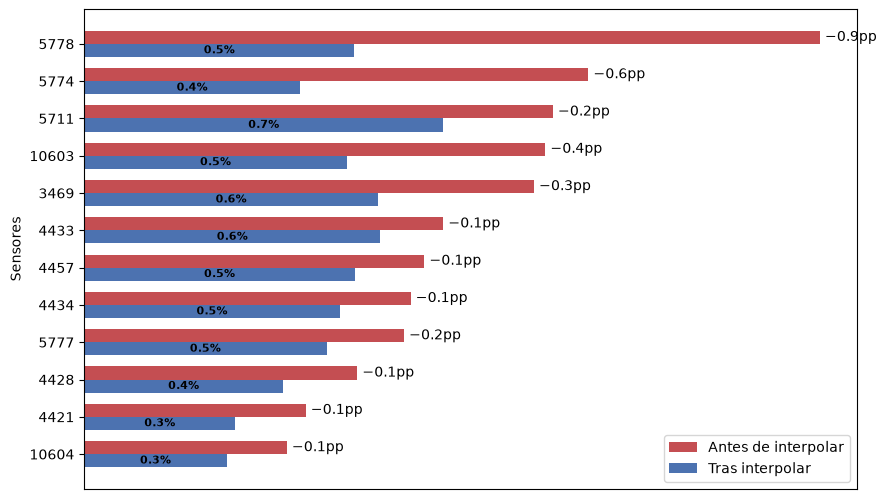


Reducción de nulos tras interpolación (puntos porcentuales):
Todos los valores deben ser ≥ 0
       nulos_intensidad  nulos_ocupacion  nulos_carga
4421              0.142            0.142        0.142
5774              0.580            0.580        0.580
5777              0.156            0.156        0.156
10604             0.121            0.121        0.121
3469              0.314            0.314        0.314
4428              0.149            0.149        0.149
4433              0.126            0.126        0.126
5711              0.220            0.220        0.220
4434              0.143            0.143        0.143
5778              0.936            0.936        0.936
10603             0.399            0.399        0.399
4457              0.140            0.140        0.140

Resumen de nulos por sensor (valores absolutos):
        instantes_totales  nulos_pre  nulos_post  interpolados  pct_pre  pct_post  pct_interpolados
sensor                                                

In [15]:
def interpolacion_nulos(serie, limite=HUECO_MAX_INTERP):
    s = serie.copy()
    es_nulo = s.isna()
    grupo = (es_nulo != es_nulo.shift()).cumsum()
    longitud = es_nulo.groupby(grupo).transform('sum')
    interpolada = s.interpolate(method='linear', limit_direction='both')
    interpolada[es_nulo & (longitud > limite)] = np.nan
    return interpolada

for sid in IDS_SENSORES:
    for v in VARIABLES:
        series[sid][v] = interpolacion_nulos(series[sid][v])

# Renombramos las columnas de 'nulos' con el mismo prefijo para poder alinear y comparar
nulos = nulos.copy()
nulos.columns = [f'nulos_{c}' for c in nulos.columns]

nulos_interpolacion = pd.DataFrame({sid: series[sid][VARIABLES].isna().mean() for sid in IDS_SENSORES}).T
nulos_interpolacion.columns = [f'nulos_{v}' for v in VARIABLES]

reduccion = (nulos - nulos_interpolacion) * 100
print(reduccion)
print("nulos.columns:", nulos.columns.tolist())
print("nulos_interp.columns:", nulos_interpolacion.columns.tolist())
print("nulos.index:", nulos.index.tolist()[:3])
print("nulos_interp.index:", nulos_interpolacion.index.tolist()[:3])

pre    = (nulos[['nulos_carga']] * 100).rename(columns={'nulos_carga': 'pre'})
post   = (nulos_interpolacion[['nulos_carga']] * 100).rename(columns={'nulos_carga': 'post'})
mejora = reduccion[['nulos_carga']].rename(columns={'nulos_carga': 'mejora'})

resumen = pd.concat([pre, post, mejora], axis=1).sort_values('pre', ascending=True)

alto_barra = 0.35
y = np.arange(len(resumen))
fig, ax = plt.subplots(figsize=(9, 0.3 * len(IDS_SENSORES) + 1.5))
barras_pre  = ax.barh(y + alto_barra / 2, resumen['pre'],height=alto_barra, color='#C44E52', label='Antes de interpolar')
barras_post = ax.barh(y - alto_barra / 2, resumen['post'],height=alto_barra, color='#4C72B0', label='Tras interpolar')

for i, (idx, row) in enumerate(resumen.iterrows()):
    ax.text(row['post'] / 2, i - alto_barra / 2, f"{row['post']:.1f}%",va='center', ha='center', fontsize=8, color='black', fontweight='bold')
    if row['mejora'] > 0:
        ax.text(row['pre'] + 0.01, i + alto_barra / 2, f"−{row['mejora']:.1f}pp",va='center', ha='left', fontsize=10, color='black')

ax.set_yticks(y)
ax.set_ylabel('Sensores', fontsize=10)
ax.set_yticklabels(resumen.index)
ax.legend(loc='lower right', fontsize=10)
ax.xaxis.set_visible(False)
plt.tight_layout()
plt.savefig(CARPETA_SALIDA / "nulos_sensor_resumen_interpolacion.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Verificacion
print("\nReducción de nulos tras interpolación (puntos porcentuales):")
print("Todos los valores deben ser ≥ 0")
print(reduccion.round(3).to_string())
total_instantes = len(rejilla)

nulos_abs = pd.DataFrame({
    sid: {
        'instantes_totales': total_instantes,
        'nulos_pre':  round(nulos.loc[sid, 'nulos_carga'] * total_instantes),
        'nulos_post': round(nulos_interpolacion.loc[sid, 'nulos_carga'] * total_instantes)}for sid in IDS_SENSORES}).T

nulos_abs['interpolados']    = nulos_abs['nulos_pre'] - nulos_abs['nulos_post']
nulos_abs['pct_pre']         = (nulos_abs['nulos_pre']  / total_instantes * 100).round(2)
nulos_abs['pct_post']        = (nulos_abs['nulos_post'] / total_instantes * 100).round(2)
nulos_abs['pct_interpolados'] = (nulos_abs['interpolados'] / total_instantes * 100).round(2)

nulos_abs = nulos_abs.sort_values('nulos_pre', ascending=False)
nulos_abs.index.name = 'sensor'

print("\nResumen de nulos por sensor (valores absolutos):")
print(nulos_abs.to_string())

print(f"\nTotal nulos pre-interpolación  (todos sensores): "
      f"{int(nulos_abs['nulos_pre'].sum()):,} instantes")
print(f"Total nulos post-interpolación (todos sensores): "
      f"{int(nulos_abs['nulos_post'].sum()):,} instantes")
print(f"Total instantes interpolados                   : "
      f"{int(nulos_abs['interpolados'].sum()):,} instantes")

### Outliers
Los valores atípicos se detectan aplicando el criterio del rango intercuartílico dentro de cada grupo definido por la combinación de hora del día y tipología. Esta agrupación es esencial en el contexto del tráfico: un valor elevado a las ocho de la mañana de un día laborable es un pico legítimo, no una anomalía, por lo que cada registro se compara únicamente con otros del mismo tipo.

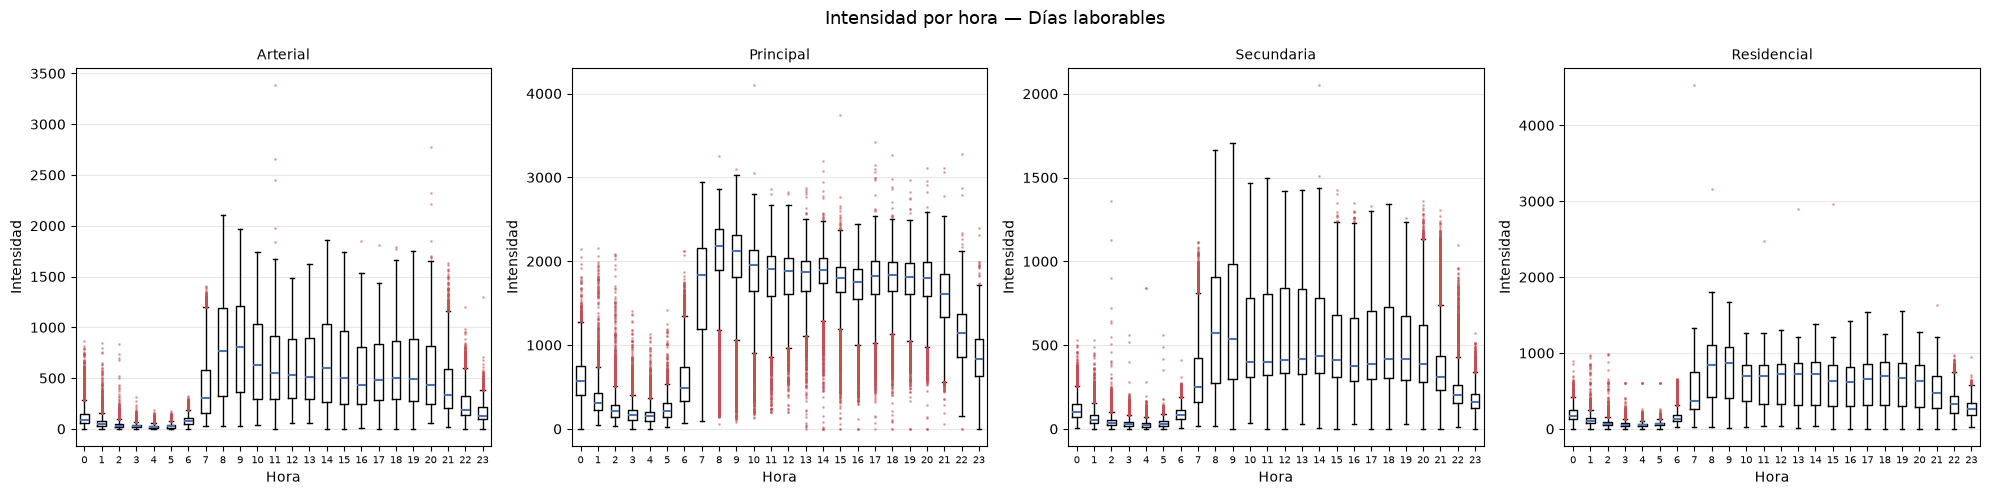

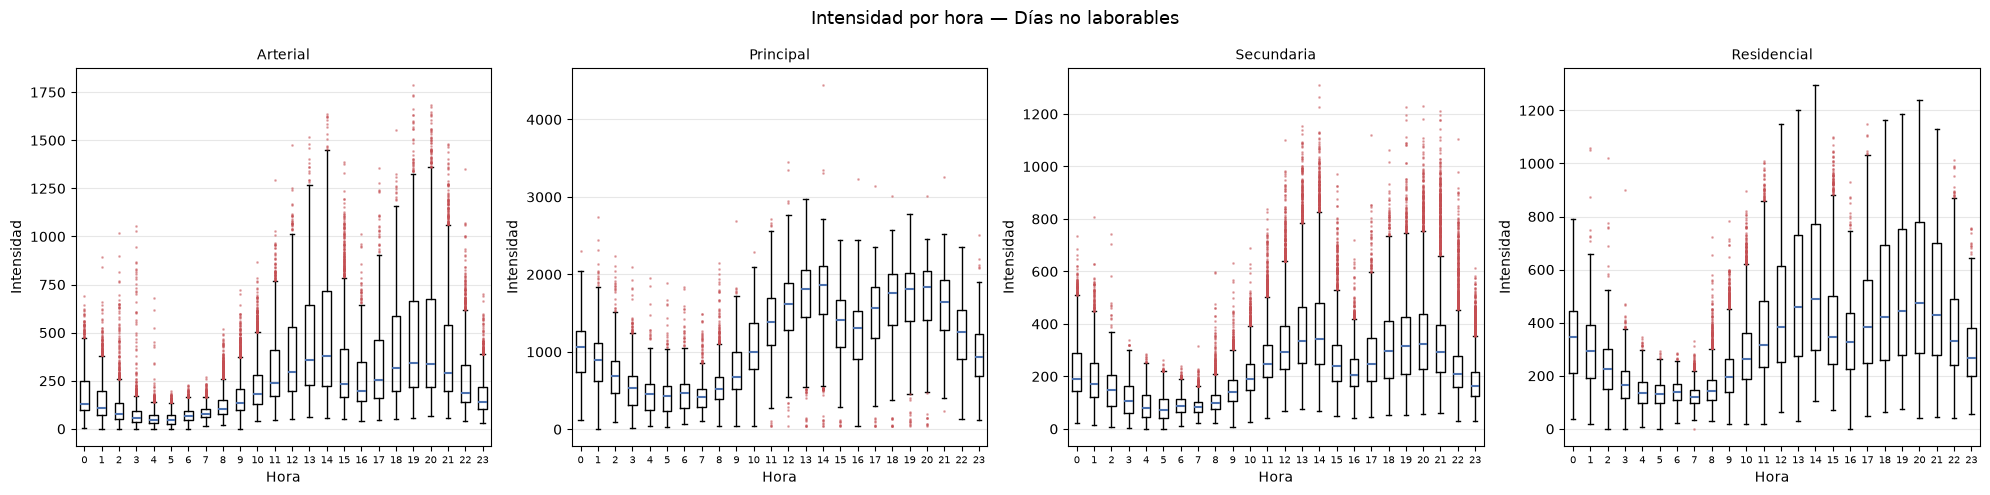

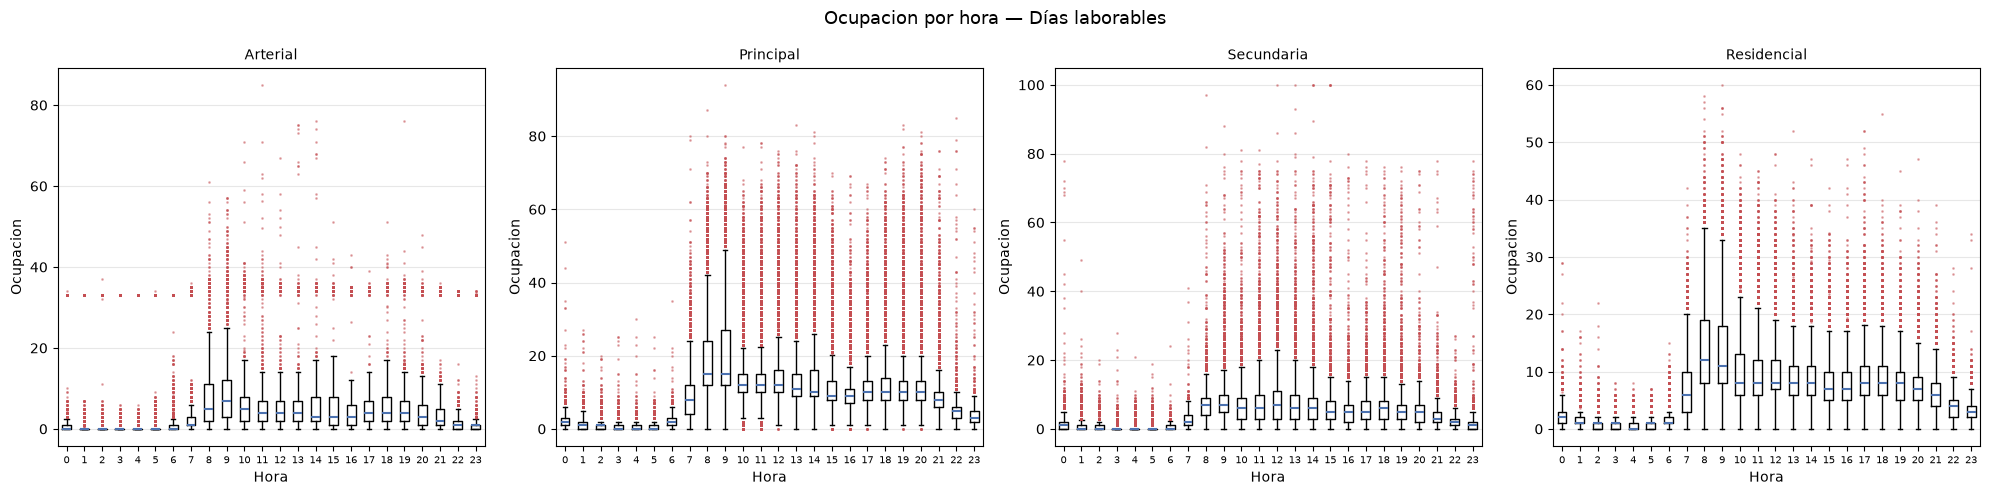

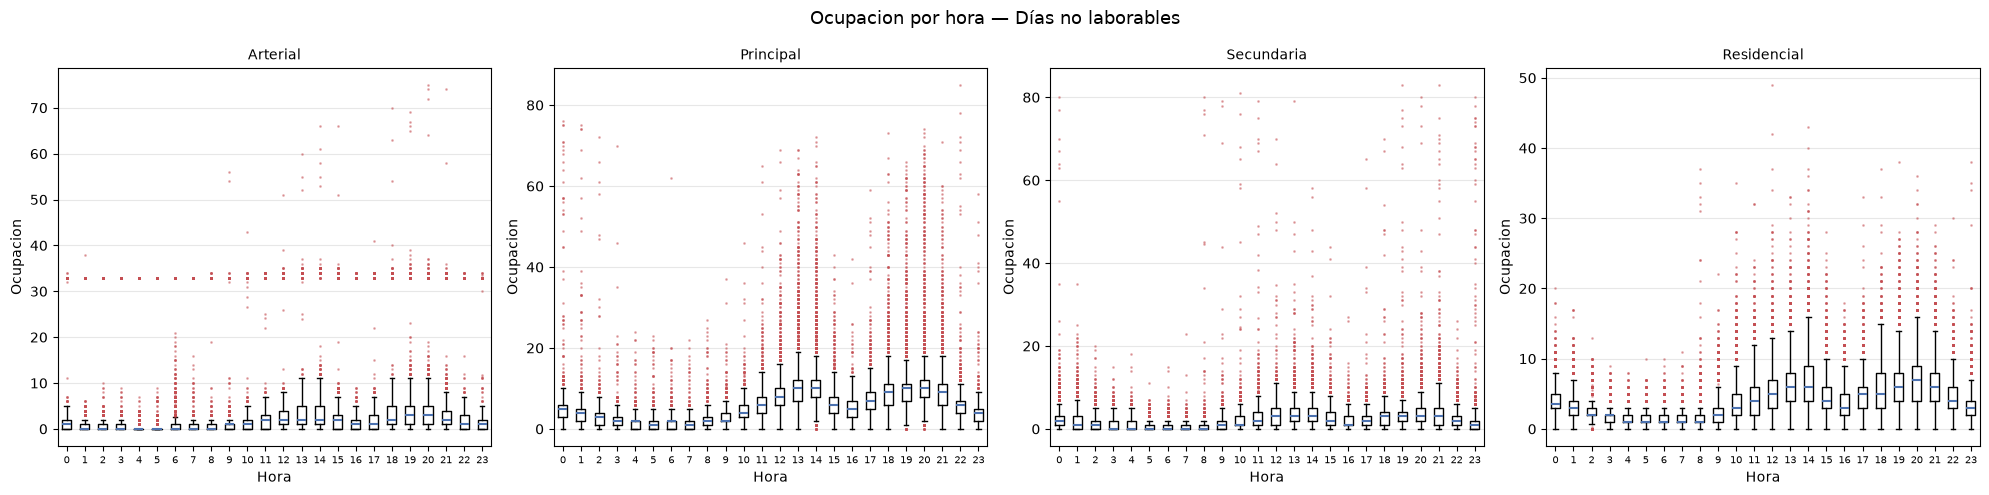

In [16]:
GRUPOS_TIPOLOGIA = {
    'Arterial':    ['5774', '5777', '10603'],
    'Principal':   ['4421', '4433', '5711'],
    'Secundaria':  ['5778', '4457', '4428'],
    'Residencial': ['3469', '4434', '10604']}

for v in ['intensidad', 'ocupacion']:
    for laborable, etiqueta in [(True, 'laborable'), (False, 'no_laborable')]:

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        axes = axes.flatten()

        for ax, (tipo, sensores) in zip(axes, GRUPOS_TIPOLOGIA.items()):
            datos = pd.concat([series[sid][v] for sid in sensores]).dropna()
            datos_df = datos.to_frame(v)
            datos_df['hora'] = datos_df.index.hour
            datos_df['laborable'] = datos_df.index.dayofweek < 5

            # Filtrar por tipo de día
            datos_filtrado = datos_df[datos_df['laborable'] == laborable]
            grupos = [datos_filtrado[datos_filtrado['hora'] == h][v].values
                      for h in range(24)]

            ax.boxplot(grupos,
                       positions=range(24),
                       showfliers=True,
                       flierprops=dict(marker='.', markersize=2,
                                       alpha=0.4, markerfacecolor='#C44E52',
                                       markeredgecolor='#C44E52'),
                       medianprops=dict(color='#4C72B0', linewidth=1.5),
                       boxprops=dict(color='black'),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'))

            ax.set_title(f'{tipo}', fontsize=10)
            ax.set_xlabel('Hora')
            ax.set_ylabel(v.capitalize())
            ax.set_xticks(range(24))
            ax.set_xticklabels(range(24), fontsize=7)
            ax.grid(axis='y', alpha=0.3)

        tipo_dia = 'Días laborables' if laborable else 'Días no laborables'
        fig.suptitle(f'{v.capitalize()} por hora — {tipo_dia}', fontsize=13)
        plt.tight_layout()
        plt.savefig(CARPETA_SALIDA / f"boxplot_hora_{v}_{etiqueta}.png",
                    dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

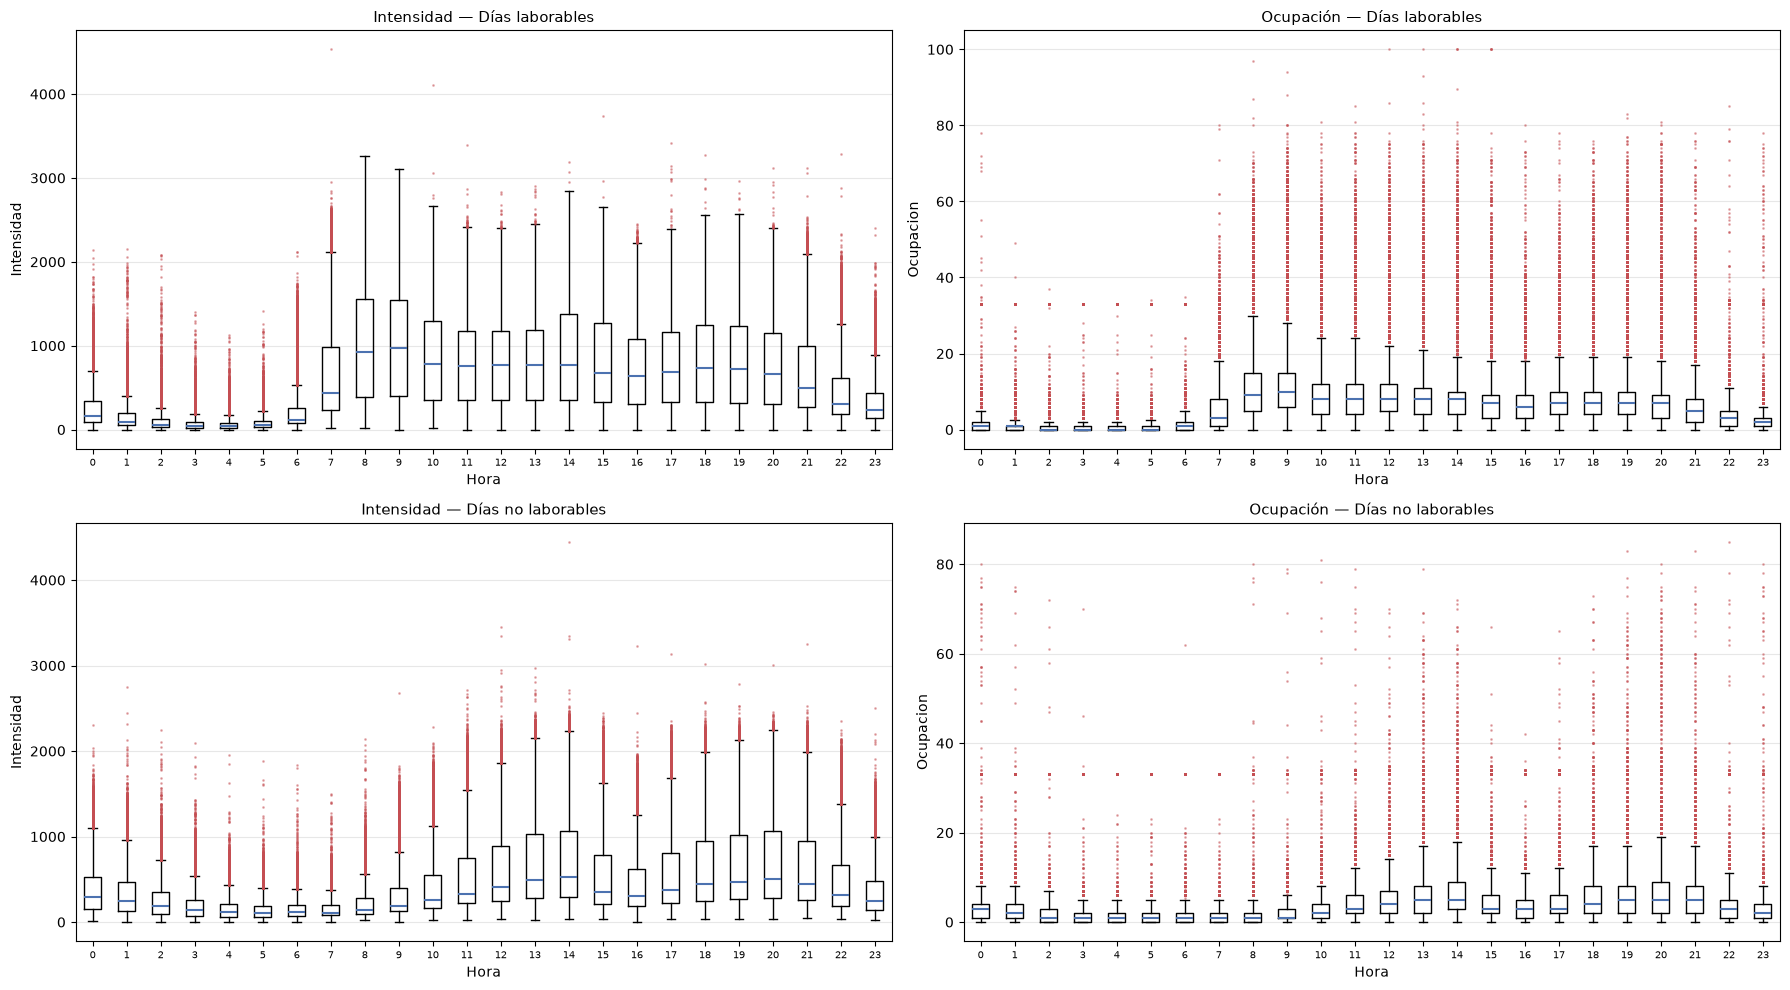

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

configs = [
    (0, 0, 'intensidad', True,  'Intensidad — Días laborables'),
    (0, 1, 'ocupacion',  True,  'Ocupación — Días laborables'),
    (1, 0, 'intensidad', False, 'Intensidad — Días no laborables'),
    (1, 1, 'ocupacion',  False, 'Ocupación — Días no laborables')]

for fila, col, v, laborable, titulo in configs:
    ax = axes[fila, col]

    datos = pd.concat([series[sid][v] for sid in IDS_SENSORES]).dropna()
    datos_df = datos.to_frame(v)
    datos_df['hora'] = datos_df.index.hour
    datos_df['laborable'] = datos_df.index.dayofweek < 5

    datos_filtrado = datos_df[datos_df['laborable'] == laborable]
    grupos = [datos_filtrado[datos_filtrado['hora'] == h][v].values
              for h in range(24)]

    ax.boxplot(grupos,
               positions=range(24),
               showfliers=True,
               flierprops=dict(marker='.', markersize=2,
                               alpha=0.4, markerfacecolor='#C44E52',
                               markeredgecolor='#C44E52'),
               medianprops=dict(color='#4C72B0', linewidth=1.5),
               boxprops=dict(color='black'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))

    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Hora')
    ax.set_ylabel(v.capitalize())
    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / "boxplot_hora_lab_2x2.png",
            dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## Guardar dataset limpio

Las series limpias de los doce sensores se consolidan en un único DataFrame en formato largo, con el identificador de sensor y su tipología como columnas. El resultado se almacena en formato Parquet, que preserva los tipos de datos y resulta eficiente para la lectura en las fases posteriores.

In [18]:
frames = []
for sid in IDS_SENSORES:
    tmp = series[sid].copy()
    tmp['id'] = sid
    tmp['tipologia'] = TIPOLOGIA[sid]
    frames.append(tmp.reset_index())

df_limpio = pd.concat(frames, ignore_index=True)
df_limpio = df_limpio[['fecha', 'id', 'tipologia'] + VARIABLES]

print(f"Registros finales: {len(df_limpio):,}")
print(f"Sensores: {df_limpio['id'].nunique()}")
print(f"Rango: {df_limpio['fecha'].min()} a {df_limpio['fecha'].max()}")
print(f"Nulos restantes por variable:")
print(df_limpio[VARIABLES].isna().sum())

df_limpio.to_csv(CARPETA_SALIDA / 'sensores_chamberi_limpio.csvt', index=False)

Registros finales: 1,262,592
Sensores: 12
Rango: 2023-01-01 00:00:00 a 2025-12-31 23:45:00
Nulos restantes por variable:
intensidad    6264
ocupacion     6264
carga         6264
dtype: int64


Antes de comenzar con el análisis temporal, se vuelve a estudiar la distribución de la variable objetivo observando que tras el tratamiento los coefeicientes no han sufrido cambios, reflejando que la limpieza fue conservadora y no deformó la variable objetivo.

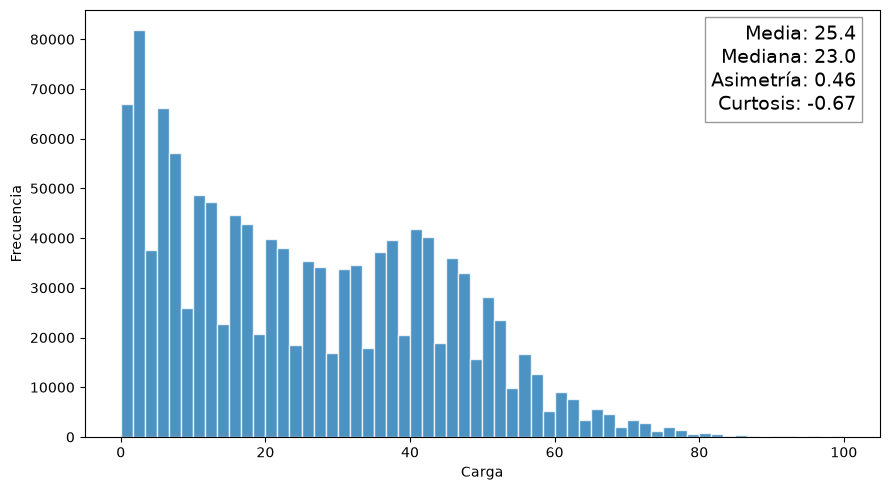

Media sin limpiar: 25.5
Mediana sin limpiar: 23.0
Asimetría sin limpiar: 0.46
Curtosis sin limpiar: -0.68


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_limpio['carga'], bins=60, color='#1f77b4', alpha=0.8, edgecolor='white')
media_act = df_limpio['carga'].mean()
mediana_act = df_limpio['carga'].median()
asimetria_act = stats.skew(df_limpio['carga'].dropna())
curtosis_act = stats.kurtosis(df_limpio['carga'].dropna(), fisher=True)

texto = ( f"Media: {media_act:.1f}\n"f"Mediana: {mediana_act:.1f}\n"f"Asimetría: {asimetria_act :.2f}\n" f"Curtosis: {curtosis_act:.2f}")
ax.text(0.97, 0.97, texto,transform=ax.transAxes,fontsize=14,va="top",ha="right",bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

ax.set_xlabel('Carga')
ax.set_ylabel('Frecuencia')
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'distribucion_carga_limpia.png', dpi=150)
plt.show()
media_ant = df['carga'].mean()
mediana_ant = df['carga'].median()
asimetria_ant = stats.skew(df['carga'].dropna())
curtosis_ant = stats.kurtosis(df['carga'].dropna(), fisher=True)

print(f'Media sin limpiar: {media_ant:.1f}\nMediana sin limpiar: {mediana_ant:.1f}\nAsimetría sin limpiar: {asimetria_ant:.2f}\nCurtosis sin limpiar: {curtosis_ant:.2f}')

## Análisis de la serie temporal

Una vez limpios los datos, se caracterizan las propiedades de la serie con el fin de fundamentar las decisiones metodológicas posteriores, en particular la elección de los modelos de aprendizaje automático. El análisis se ilustra sobre la serie agregada de la variable objetivo `carga`, promediada entre los doce sensores para cada instante.

Se analizan los perfiles medios de carga por mes, las diferencias entre días laborables y no laborables, y la evolución horaria durante los días laborables para las distintas tipologías de vía. 

In [20]:
serie = (df_limpio.groupby('fecha')['carga'].mean().asfreq(FREQ))
print(f"Longitud de la serie agregada: {len(serie):,}")
print(f"Nulos: {serie.isna().sum()}")

Longitud de la serie agregada: 105,216
Nulos: 260


In [21]:
# Verificación
nulos_por_sensor = df_limpio.groupby('id')['carga'].apply(lambda x: x.isna().sum())
print("Nulos por sensor en df_limpio:")
print(nulos_por_sensor.to_string())
print(f"\nTotal: {nulos_por_sensor.sum():,}")

# Comparar con lo calculado antes
nulos_series = pd.Series({
    sid: series[sid]['carga'].isna().sum() for sid in IDS_SENSORES
})
print("\nNulos por sensor en series[]:")
print(nulos_series.to_string())
print(f"\nTotal: {nulos_series.sum():,}")

Nulos por sensor en df_limpio:
id
10603    556
10604    302
3469     622
4421     320
4428     421
4433     627
4434     541
4457     573
5711     760
5774     457
5777     513
5778     572

Total: 6,264

Nulos por sensor en series[]:
4421     320
5774     457
5777     513
10604    302
3469     622
4428     421
4433     627
5711     760
4434     541
5778     572
10603    556
4457     573

Total: 6,264


### Perfiles temporales

Se analizan los perfiles medios de carga por mes, las diferencias entre días laborables y no laborables, y la evolución horaria durante los días laborables para las distintas tipologías de vía. Este análisis permite identificar los patrones cíclicos característicos del tráfico urbano y justifica el empleo de transformaciones seno-coseno en las variables temporales, al preservar la naturaleza periódica de ciclos como la hora del día o el mes del año.

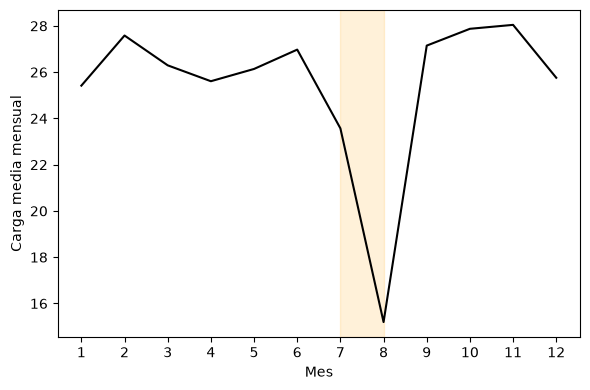

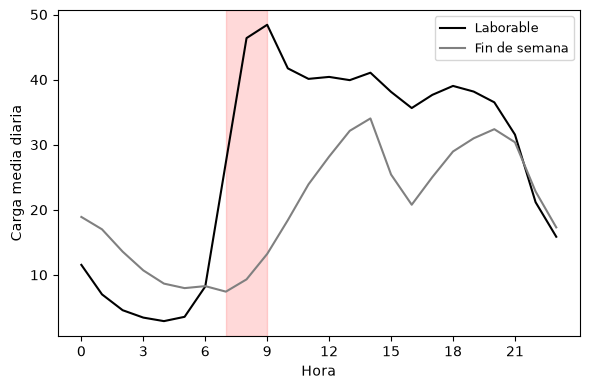

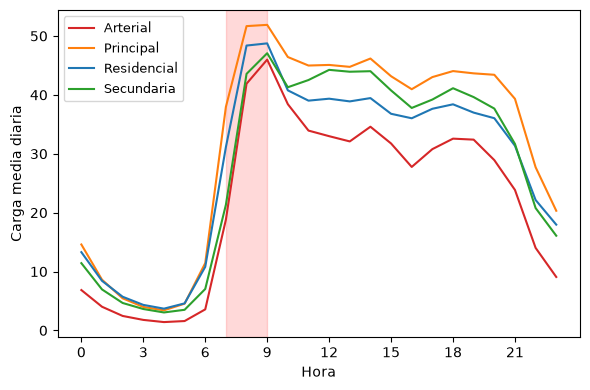

In [22]:
#Carga media por mes
fig, ax = plt.subplots(figsize=(6, 4))
por_mes = df_limpio.groupby(df_limpio['fecha'].dt.month)['carga'].mean()
ax.plot(por_mes.index, por_mes.values, color='black')
ax.axvspan(7, 8, alpha=0.15, color='orange')
ax.set_xlabel('Mes')
ax.set_ylabel('Carga media mensual')
ax.set_xticks(range(1, 13))
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'perfil_mes.png', dpi=300, bbox_inches='tight')
plt.show()

#Carga media por tipo de día 
fig, ax = plt.subplots(figsize=(6, 4))
d_lab = df_limpio[df_limpio['carga'] >= 0].copy()
d_lab['hora'] = d_lab['fecha'].dt.hour
d_lab['laborable'] = d_lab['fecha'].dt.dayofweek < 5

for lab, etq, color in [(True, 'Laborable', 'black'),
                         (False, 'Fin de semana', 'grey')]:
    perfil = d_lab[d_lab['laborable'] == lab].groupby('hora')['carga'].mean()
    ax.plot(perfil.index, perfil.values, label=etq,color=color, linewidth=1.5)
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.set_xlabel('Hora')
ax.set_ylabel('Carga media diaria')
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'perfil_tipo_dia.png', dpi=300, bbox_inches='tight')
plt.show()

#Carga media días laborables por hora y tipología
COLORES_TIPOLOGIAS = {
    'Arterial':    '#d62728',
    'Principal':   '#ff7f0e',
    'Secundaria':  '#2ca02c',
    'Residencial': '#1f77b4'}
fig, ax = plt.subplots(figsize=(6, 4))

d_lab['tipologia'] = d_lab['id'].map(TIPOLOGIA)

sub = d_lab[d_lab['laborable']]
for lab in sorted(sub['tipologia'].dropna().unique()):
    perfil = sub[sub['tipologia'] == lab].groupby('hora')['carga'].mean()
    ax.plot(perfil.index, perfil.values, label=lab,color=COLORES_TIPOLOGIAS.get(lab))
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.set_xlabel('Hora')
ax.set_ylabel('Carga media diaria')
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'perfil_tipologia_laborable.png', dpi=300, bbox_inches='tight')
plt.show()

### Estacionariedad: test de Dickey-Fuller aumentado

Se aplica el test de Dickey-Fuller aumentado para comprobar si la estructura de la serie depende del tiempo. La hipótesis nula del test es la  la no estacionariedad. 

In [23]:
# ADF H0: no estacionaria
serie_sinnulos =serie.dropna() # eliminamos nulos de la serie
from statsmodels.tsa.stattools import adfuller
adf = adfuller(serie_sinnulos, autolag='AIC')
print("Test de Dickey-Fuller aumentado (ADF)")
print(f"Estadístico ADF: {adf[0]:.4f}")
print(f"p-valor:         {adf[1]:.2e}")
print("Valores críticos:")
for k, v in adf[4].items():
    print(f"   {k}: {v:.4f}")
print("Se rechaza la hipótesis nula. La serie es estacionaria." if adf[1] < 0.05
      else "La serie no es estacionaria")

Test de Dickey-Fuller aumentado (ADF)
Estadístico ADF: -33.0506
p-valor:         0.00e+00
Valores críticos:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Se rechaza la hipótesis nula. La serie es estacionaria.


### Autocorrelación simple y parcial

Las funciones de autocorrelación simple (ACF) y parcial (PACF) identifican los desfases temporales en los que existe una dependencia relevante entre registros. 

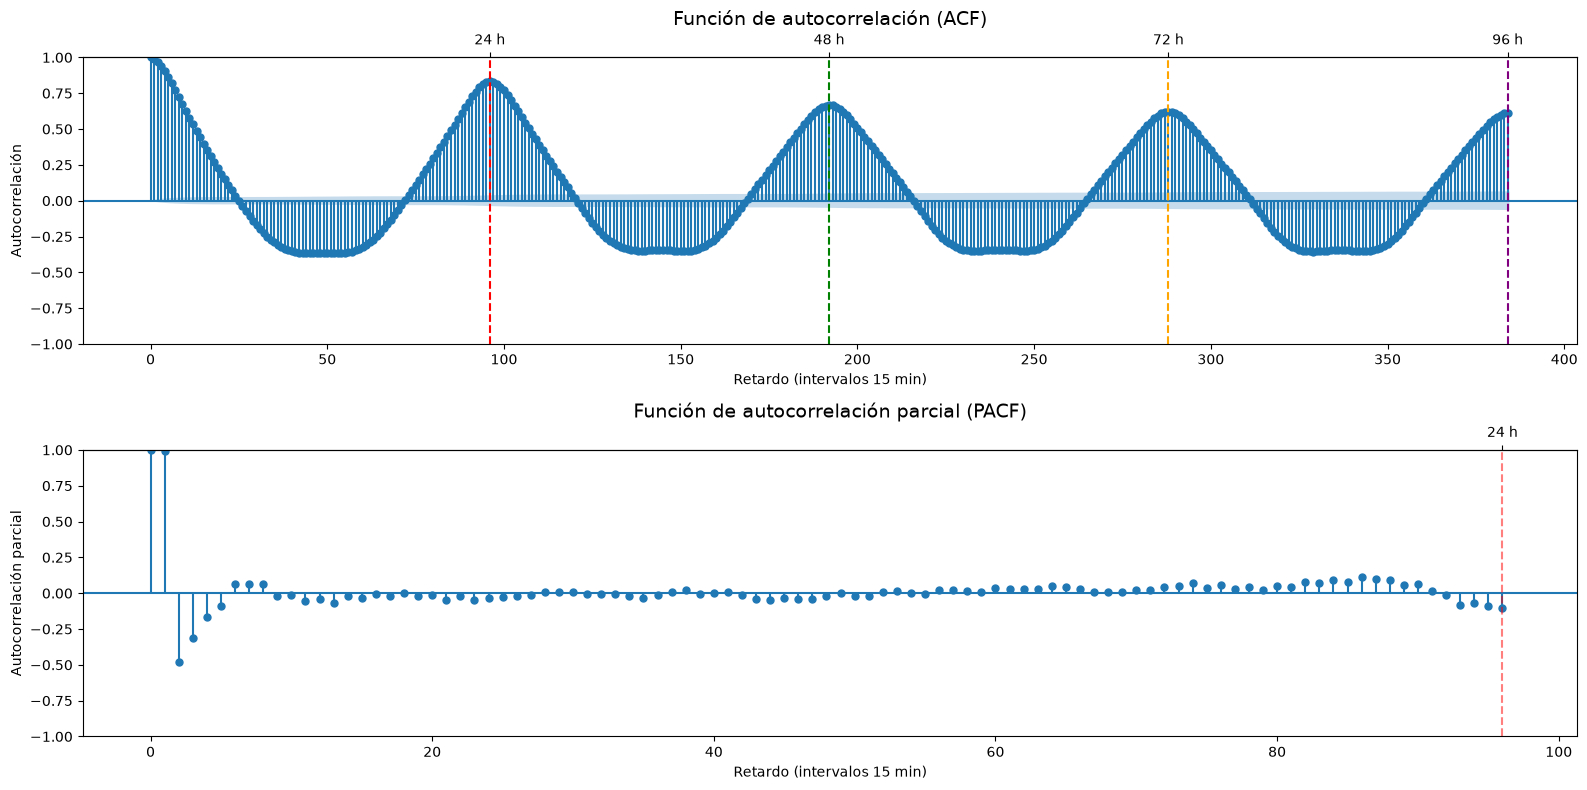

In [ ]:
# ACF y PACF
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── ACF hasta 96 h (4 días completos) ─────────────────────────────────────────
plot_acf(serie_sinnulos, lags=384, ax=axes[0], alpha=0.05)
for lag, color in [(96, 'red'), (192, 'green'), (288, 'orange'), (384, 'purple')]:
    axes[0].axvline(lag, color=color, ls='--', alpha=1)
axes[0].set_xlabel('Retardo (intervalos 15 min)')
axes[0].set_ylabel('Autocorrelación')
axes[0].set_title('Función de autocorrelación (ACF)', fontsize=14)

secax0 = axes[0].secondary_xaxis('top')
secax0.set_xticks([96, 192, 288, 384])
secax0.set_xticklabels(['24 h', '48 h', '72 h', '96 h'])
secax0.tick_params(labelsize=10)

# PACF hasta 24 h (96 lags)
plot_pacf(serie_sinnulos, lags=96, ax=axes[1], method='ywm', alpha=0.05)
axes[1].axvline(96, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('Retardo (intervalos 15 min)')
axes[1].set_ylabel('Autocorrelación parcial')
axes[1].set_title('Función de autocorrelación parcial (PACF)', fontsize=14)

secax1 = axes[1].secondary_xaxis('top')
secax1.set_xticks([96])
secax1.set_xticklabels(['24 h'])
secax1.tick_params(labelsize=10)

fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

# Transformación

## Ingeniería de características

In [25]:
def ing_carac(df):
    d = df.copy()
    hora = d['fecha'].dt.hour + d['fecha'].dt.minute / 60
    dia  = d['fecha'].dt.dayofweek        
    mes  = d['fecha'].dt.month
    
    # Variables temporales cíclicas
    d['hora_sin'] = np.sin(2 * np.pi * hora / 24)
    d['hora_cos'] = np.cos(2 * np.pi * hora / 24)
    d['dia_sin']  = np.sin(2 * np.pi * dia / 7)
    d['dia_cos']  = np.cos(2 * np.pi * dia / 7)
    d['mes_sin']  = np.sin(2 * np.pi * mes / 12)
    d['mes_cos']  = np.cos(2 * np.pi * mes / 12)
    
    # Variables binarias
    d['es_laborable'] = (dia < 5).astype(int)
    d['es_verano']       = mes.isin([7, 8]).astype(int)

    # Transformación de categóricas a binarias
    # Se elimina el prefijo de letra ('A-', 'B-'...) y se pasa a minúsculaa. Se descarta 'residencial', que actúa como categoría de referencia.
    tipo_limpio = d['tipologia'].str.split('-').str[-1].str.lower()
    tipologia_dummies = pd.get_dummies(tipo_limpio,prefix='es',dtype=int,).drop(columns='es_residencial')
    d = pd.concat([d, tipologia_dummies], axis=1)

    return d

df_features = ing_carac(df_limpio)
df_features = df_features.dropna(subset=['carga', 'intensidad', 'ocupacion'])

print(f"Dataset tras ingeniería de características: {len(df_features):,} filas")
print(df_features.head())
FEATURES = ['intensidad', 'ocupacion', 'hora_sin', 'hora_cos','dia_sin',  'dia_cos', 'mes_sin',  'mes_cos','es_laborable','es_verano','es_arterial','es_principal','es_secundaria']
TARGET = 'carga'


Dataset tras ingeniería de características: 1,256,328 filas
                fecha    id  tipologia  intensidad  ocupacion  carga  \
0 2023-01-01 00:00:00  4421  Principal       163.0        0.0    4.0   
1 2023-01-01 00:15:00  4421  Principal       172.0        0.0    3.0   
2 2023-01-01 00:30:00  4421  Principal       488.0        1.0    7.0   
3 2023-01-01 00:45:00  4421  Principal      1051.0        4.0   19.0   
4 2023-01-01 01:00:00  4421  Principal      1622.0        7.0   33.0   

   hora_sin  hora_cos   dia_sin  dia_cos  mes_sin   mes_cos  es_laborable  \
0  0.000000  1.000000 -0.781831  0.62349      0.5  0.866025             0   
1  0.065403  0.997859 -0.781831  0.62349      0.5  0.866025             0   
2  0.130526  0.991445 -0.781831  0.62349      0.5  0.866025             0   
3  0.195090  0.980785 -0.781831  0.62349      0.5  0.866025             0   
4  0.258819  0.965926 -0.781831  0.62349      0.5  0.866025             0   

   es_verano  es_arterial  es_principal  es_

## Guardar datos limpios y con la ingeniería de características

In [27]:
COLUMNAS_GUARDAR = ['fecha', 'id', 'tipologia'] + FEATURES + [TARGET]

faltan = df_features[COLUMNAS_GUARDAR].isna().sum()
if faltan.sum() > 0:
    print("Aviso: columnas con nulos antes de guardar:")
    print(faltan[faltan > 0].to_string())
else:
    print("Sin nulos en las columnas a exportar.")

df_modelo = df_features[COLUMNAS_GUARDAR].sort_values(['id', 'fecha']).reset_index(drop=True)

RUTA_DATASET_MODELO = CARPETA_SALIDA / 'dataset_modelo.csv'
df_modelo.to_csv(RUTA_DATASET_MODELO, index=False)

print(f"\nDataset guardado en: {RUTA_DATASET_MODELO}")
print(f"Registros: {len(df_modelo):,}")
print(f"Columnas ({len(df_modelo.columns)}): {list(df_modelo.columns)}")
print(f"Rango temporal: {df_modelo['fecha'].min()} a {df_modelo['fecha'].max()}")
print(f"Sensores: {df_modelo['id'].nunique()}")

Sin nulos en las columnas a exportar.

Dataset guardado en: C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\preprocesamiento-transformacion\dataset_modelo.csv
Registros: 1,256,328
Columnas (17): ['fecha', 'id', 'tipologia', 'intensidad', 'ocupacion', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'es_laborable', 'es_verano', 'es_arterial', 'es_principal', 'es_secundaria', 'carga']
Rango temporal: 2023-01-01 00:00:00 a 2025-12-31 23:45:00
Sensores: 12
